In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_excel("glass.xlsx", sheet_name=1)

df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [39]:
df.shape

(214, 10)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [41]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [42]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [43]:
df.duplicated().sum()

np.int64(1)

In [44]:
df = df.drop_duplicates()

df.shape

(213, 10)

In [45]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

### Histograms

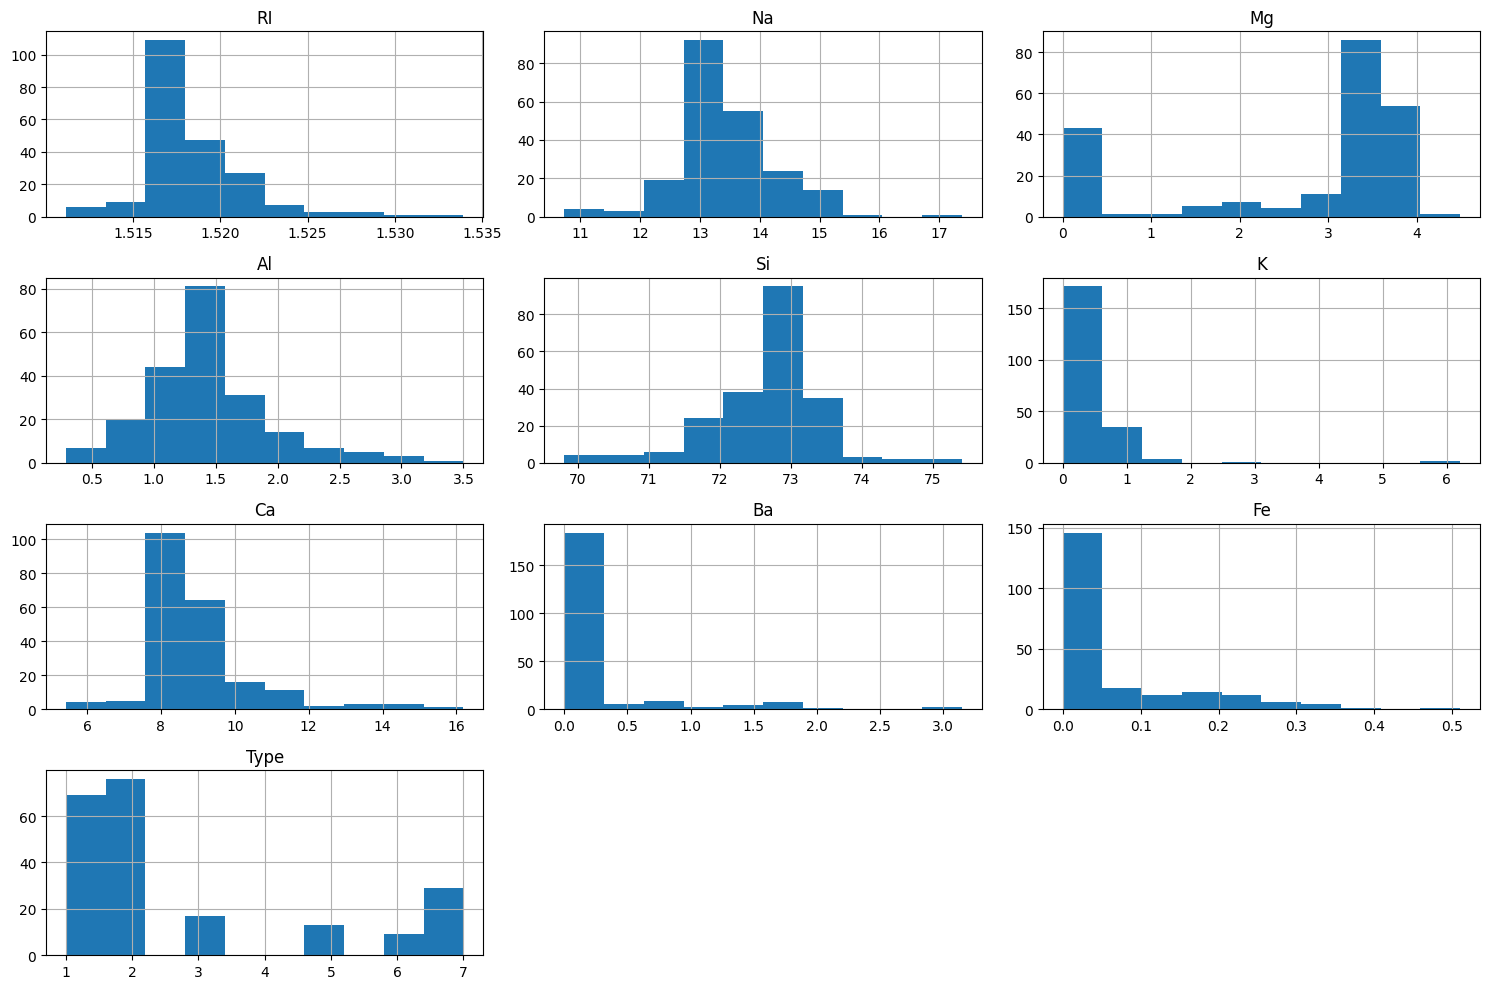

In [46]:
df.hist(figsize=(15,10))

plt.tight_layout()
plt.show()

### Box Plots (Outlier Detection)

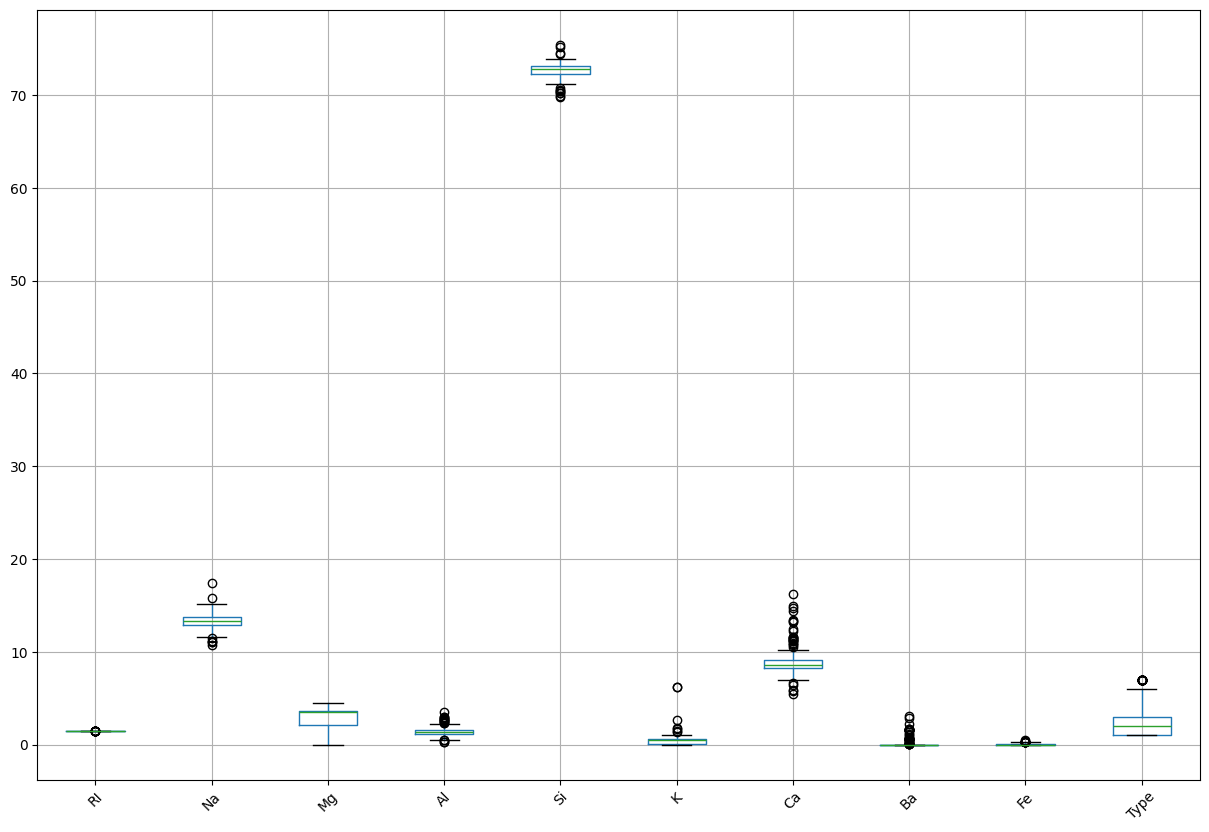

In [47]:
plt.figure(figsize=(15,10))

df.boxplot()

plt.xticks(rotation=45)
plt.show()

### Outlier Treatment Using IQR Method

In [48]:
Q1 = df.quantile(0.25)

Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df_outlier = df[
    ~((df < (Q1 - 1.5 * IQR)) |
      (df > (Q3 + 1.5 * IQR))).any(axis=1)
]

df_outlier.shape

(135, 10)

### Pair Plot

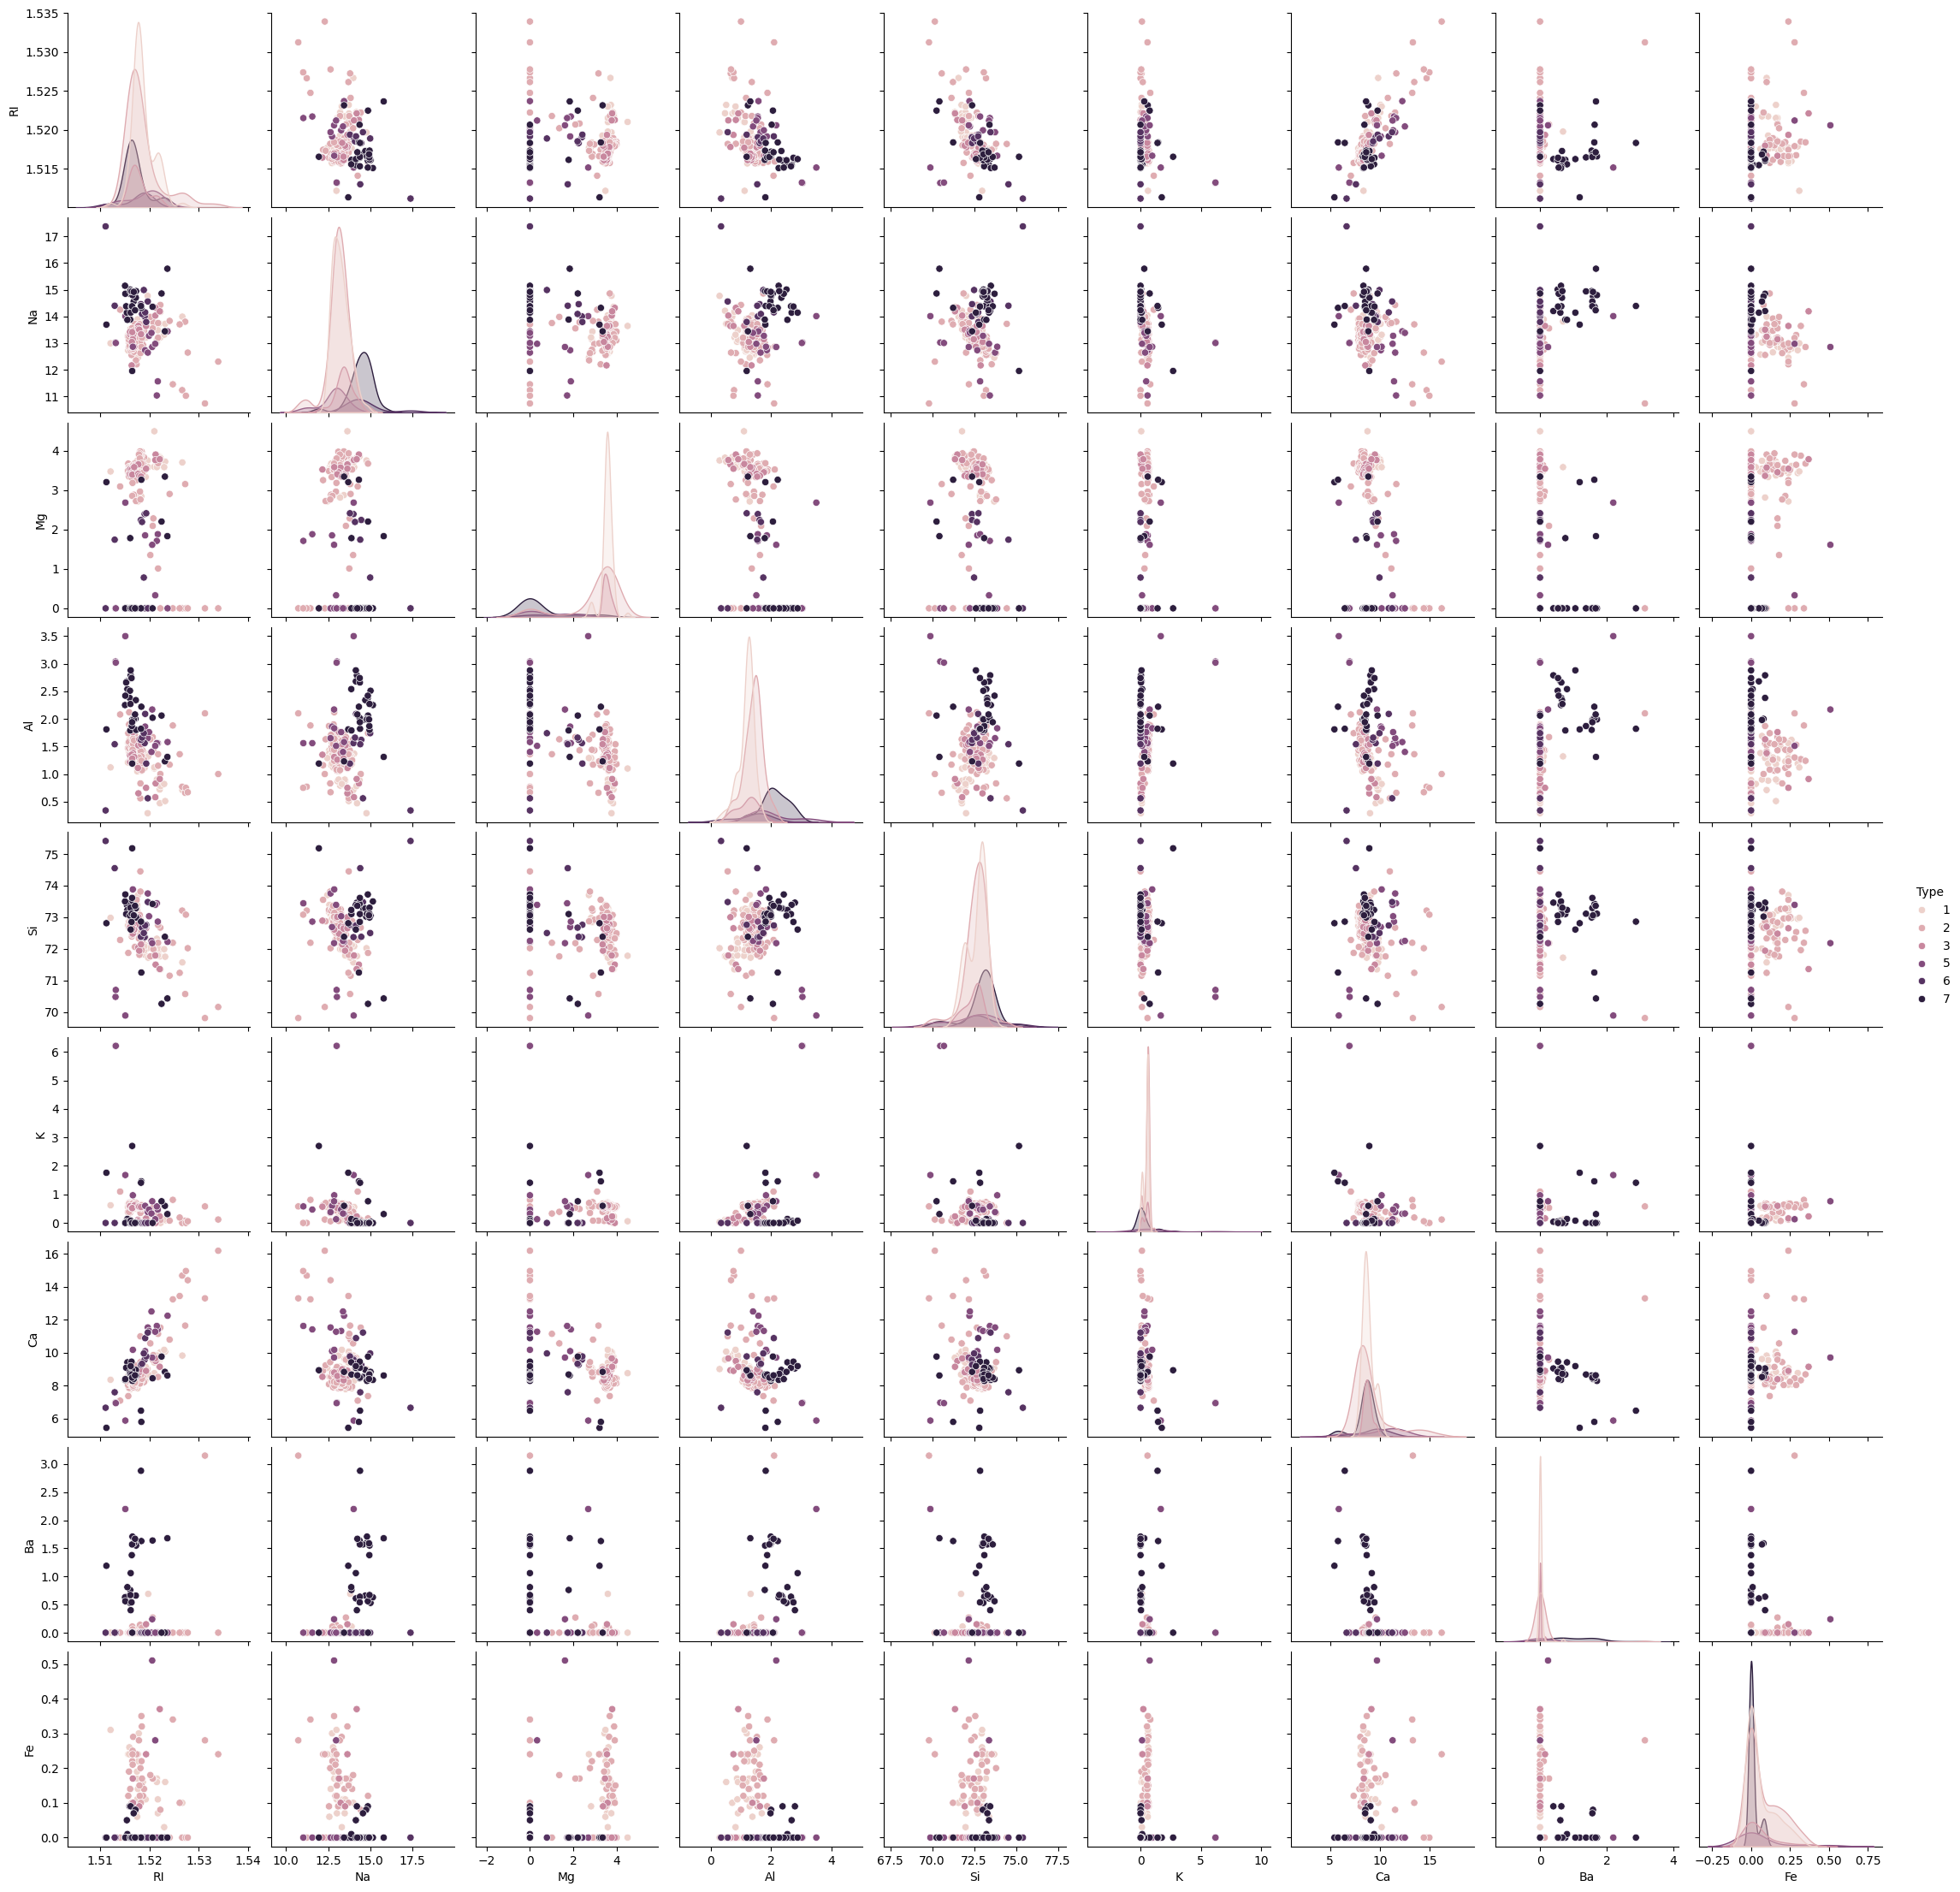

In [49]:
sns.pairplot(df, hue='Type')

plt.show()

### Correlation Matrix

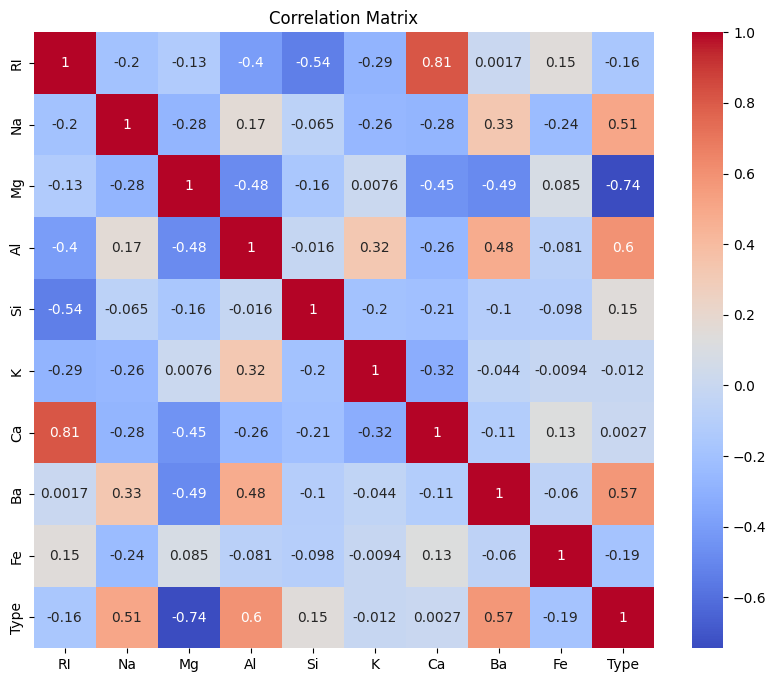

In [50]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

### Check Class Imbalance

In [51]:
df['Type'].value_counts()

Type
2    76
1    69
7    29
3    17
5    13
6     9
Name: count, dtype: int64

### Visualize Class Distribution

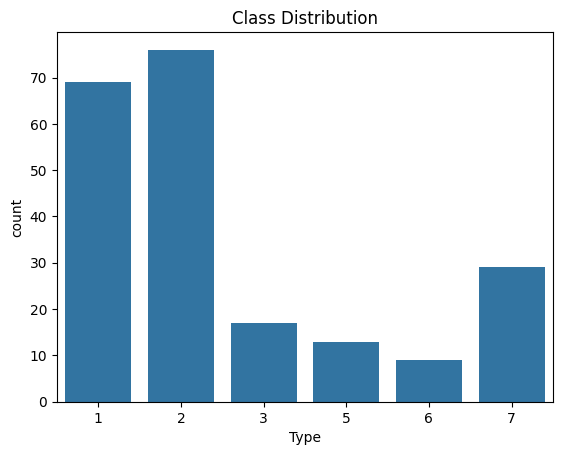

In [52]:
sns.countplot(x='Type', data=df)

plt.title("Class Distribution")
plt.show()

### Update Features and Target

In [53]:
X = df_outlier.drop('Type', axis=1)

y = df_outlier['Type']

### Feature Scaling

In [54]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Type', axis=1)
y = df['Type']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Train-Test Split

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(170, 9)
(43, 9)


### Random Forest Model

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Model Prediction & Evaluation

In [57]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred, average='weighted'))

print("Recall:",
      recall_score(y_test, y_pred, average='weighted'))

print("F1 Score:", 
      f1_score(y_test, y_pred, average='weighted'))

print(classification_report(y_test, y_pred))

Accuracy: 0.7674418604651163
Precision: 0.7823920265780729
Recall: 0.7674418604651163
F1 Score: 0.7628818969448244
              precision    recall  f1-score   support

           1       0.71      1.00      0.83        10
           2       0.67      0.67      0.67        15
           3       1.00      0.67      0.80         3
           5       0.50      0.33      0.40         3
           6       1.00      0.67      0.80         3
           7       1.00      0.89      0.94         9

    accuracy                           0.77        43
   macro avg       0.81      0.70      0.74        43
weighted avg       0.78      0.77      0.76        43



### Hyperparameter Tuning

In [58]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


### Train Best Random Forest Model

In [59]:
best_rf = grid.best_estimator_

best_rf.fit(X_train, y_train)

best_pred = best_rf.predict(X_test)

### Evaluate Tuned Model

In [60]:
print("Accuracy:",
      accuracy_score(y_test, best_pred))

print("Precision:",
      precision_score(y_test,
                      best_pred,
                      average='weighted'))

print("Recall:",
      recall_score(y_test,
                   best_pred,
                   average='weighted'))

print("F1 Score:",
      f1_score(y_test,
               best_pred,
               average='weighted'))

Accuracy: 0.7674418604651163
Precision: 0.7823920265780729
Recall: 0.7674418604651163
F1 Score: 0.7628818969448244


### Feature Importance

In [61]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

  Feature  Importance
2      Mg    0.156405
3      Al    0.142305
6      Ca    0.141800
0      RI    0.140845
1      Na    0.125651
4      Si    0.088704
5       K    0.081008
7      Ba    0.079514
8      Fe    0.043768


### Visualize Feature Importance

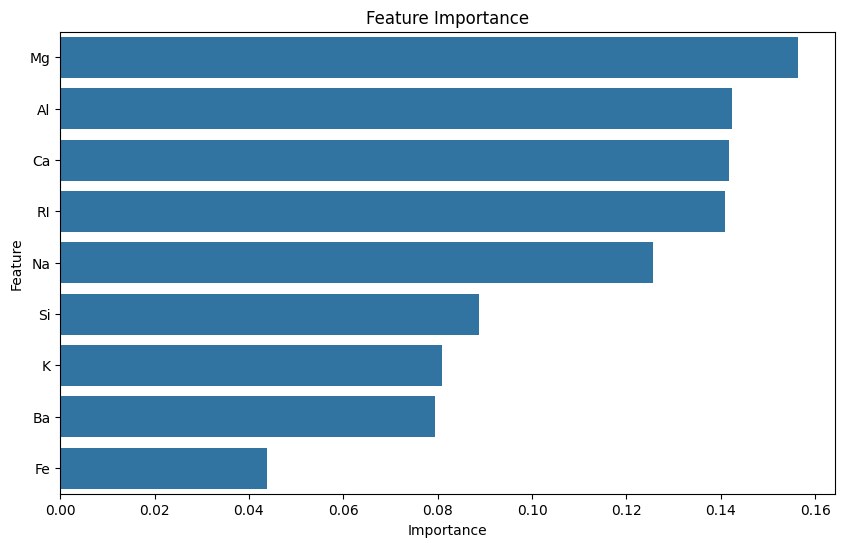

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

### Bagging Classifier

In [63]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bagging_model.fit(X_train, y_train)

bagging_pred = bagging_model.predict(X_test)

### Evaluate Bagging Model

In [64]:
print("Accuracy:",
      accuracy_score(y_test, bagging_pred))

print("Precision:",
      precision_score(y_test,
                      bagging_pred,
                      average='weighted'))

print("Recall:",
      recall_score(y_test,
                   bagging_pred,
                   average='weighted'))

print("F1 Score:",
      f1_score(y_test,
               bagging_pred,
               average='weighted'))

Accuracy: 0.813953488372093
Precision: 0.8413621262458473
Recall: 0.813953488372093
F1 Score: 0.8109634551495015


### Boosting Model (AdaBoost)

In [65]:
from sklearn.ensemble import AdaBoostClassifier

boost_model = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

boost_model.fit(X_train, y_train)

boost_pred = boost_model.predict(X_test)

### Evaluate Boosting Model

In [66]:
print("Accuracy:",
      accuracy_score(y_test, boost_pred))

print("Precision:",
      precision_score(y_test,
                      boost_pred,
                      average='weighted',
                      zero_division=0))

print("Recall:",
      recall_score(y_test,
                   boost_pred,
                   average='weighted',
                   zero_division=0))

print("F1 Score:",
      f1_score(y_test,
               boost_pred,
               average='weighted',
               zero_division=0))

Accuracy: 0.6046511627906976
Precision: 0.6025126971398022
Recall: 0.6046511627906976
F1 Score: 0.5463480432016684


### Compare Random Forest, Bagging, and Boosting

In [67]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Bagging', 'Boosting'],
    
    'Accuracy': [
        accuracy_score(y_test, best_pred),
        accuracy_score(y_test, bagging_pred),
        accuracy_score(y_test, boost_pred)
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.767442
1,Bagging,0.813953
2,Boosting,0.604651


## Analysis


###### 1. Random Forest combines multiple decision trees and improves prediction accuracy.
######
###### 2. Bagging reduces variance by training multiple models on random subsets.
######
###### 3. Boosting improves weak learners sequentially by focusing on previous errors.
######
###### 4. Random Forest generally provides better stability and accuracy.
######
###### 5. Class imbalance can affect minority class prediction.

# Additional Notes:

#### 1. Explain Bagging and Boosting methods. How is it different from each other.

###### Bagging is an ensemble technique where multiple models are trained independently on random subsets of the dataset, and their predictions are combined to improve accuracy and reduce variance. Random Forest is an example of bagging.

###### Boosting is an ensemble technique where models are trained sequentially, and each new model focuses on correcting the errors made by previous models. AdaBoost and Gradient Boosting are examples of boosting.

##### Difference:
###### Bagging trains models independently, while Boosting trains models sequentially.
###### Bagging mainly reduces variance, while Boosting mainly reduces bias.
###### Bagging is less prone to overfitting compared to Boosting.

#### 2. Explain how to handle imbalance in the data.

###### Imbalanced data can be handled using techniques such as oversampling the minority class, undersampling the majority class, and using synthetic data generation methods like SMOTE. Class weights can also be adjusted in machine learning algorithms to give more importance to minority classes. Evaluation metrics like Precision, Recall, F1-score, and ROC-AUC are preferred over accuracy for imbalanced datasets.